Environment

In [24]:
import numpy as np

GRID_SIZE = 10
ORIENTATIONS = [0, 1, 2, 3]         #for east ,north ,west, south
ACTIONS = ["F", "L", "R"]

GAMMA = 0.95
STEP_REWARD = -1
GOAL_REWARD = 50
COLLISION_REWARD = -100
OBSTACLES = {(3, 3), (3, 4), (4, 4), (6, 6), (7, 2)}
GOAL = (9, 9)

COLLISION_STATE = "COLLISION"       #Terminal state 

DIRS = {
    0: ((1, 0), (0, 1), (0, -1)),   
    1: ((0, 1), (-1, 0), (1, 0)),   
    2: ((-1, 0), (0, -1), (0, 1)),
    3: ((0, -1), (1, 0), (-1, 0)),
}

states = []
for x in range(GRID_SIZE):
    for y in range(GRID_SIZE):
        if (x, y) not in OBSTACLES:
            for theta in ORIENTATIONS:
                states.append((x, y, theta))

states.append(COLLISION_STATE)

terminal_states = {COLLISION_STATE}
for theta in ORIENTATIONS:
    terminal_states.add((GOAL[0], GOAL[1], theta))



def is_valid(x, y):
    if x < 0 or x >= GRID_SIZE or y < 0 or y >= GRID_SIZE:
        return False
    if (x, y) in OBSTACLES:
        return False
    return True


def get_transitions(state, action):                 #it will returns list of (prob, nextstate, reward)
    if state in terminal_states:
        return []

    x, y, theta = state
    transitions = []

    if action == "L":
        next_state = (x, y, (theta + 1) % 4)
        transitions.append((1.0, next_state, STEP_REWARD))

    elif action == "R":
        next_state = (x, y, (theta - 1) % 4)
        transitions.append((1.0, next_state, STEP_REWARD))

    elif action == "F":
        forward, left, right = DIRS[theta]

        moves = [
            (0.8, forward),
            (0.1, left),
            (0.1, right)
        ]

        for prob, (dx, dy) in moves:
            nx, ny = x + dx, y + dy

            if not is_valid(nx, ny):
                transitions.append((prob, COLLISION_STATE, COLLISION_REWARD))
            elif (nx, ny) == GOAL:
                transitions.append((prob, (nx, ny, theta), GOAL_REWARD))
            else:
                transitions.append((prob, (nx, ny, theta), STEP_REWARD))

    return transitions

Value_Iteration and Policy Iteration

In [25]:
import time
import tracemalloc
def run_value_iteration(states, terminal_states, ACTIONS, GAMMA, get_transitions, tol=1e-4, max_iters=1000):

    V = {s: 0.0 for s in states}
    iterations = 0

    start_time = time.time()
    tracemalloc.start()

    for k in range(max_iters):
        delta = 0
        V_new = V.copy()

        for s in states:
            if s in terminal_states:
                continue

            best_val = -float("inf")

            for a in ACTIONS:
                val = 0
                for p, s_next, r in get_transitions(s, a):
                    val += p * (r + GAMMA * V[s_next])

                best_val = max(best_val, val)

            delta = max(delta, abs(best_val - V[s]))
            V_new[s] = best_val

        V = V_new
        iterations += 1

        if delta < tol:
            break

    # Extract optimal policy
    v_policy = {}
    for s in states:
        if s in terminal_states:
            continue

        best_action = None
        best_val = -float("inf")

        for a in ACTIONS:
            val = 0
            for p, s_next, r in get_transitions(s, a):
                val += p * (r + GAMMA * V[s_next])

            if val > best_val:
                best_val = val
                best_action = a

        v_policy[s] = best_action

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    return V, v_policy, iterations, runtime, peak


#Policy Iteration until convergence
import random

def run_policy_iteration(states, terminal_states, ACTIONS, GAMMA, get_transitions, tol=1e-4, max_iters=1000):

    p_policy = {}
    for s in states:
        if s not in terminal_states:
            p_policy[s] = random.choice(ACTIONS)

    V = {}
    for s in states:
        V[s] = 0.0
        
    iterations = 0
    start_time = time.time()
    tracemalloc.start()

    for k in range(max_iters):

        # Policy Evaluation
        while True:
            delta = 0
            V_new = V.copy()

            for s in states:
                if s in terminal_states:
                    continue

                a = p_policy[s]
                val = 0
                for p, s_next, r in get_transitions(s, a):
                    val += p * (r + GAMMA * V[s_next])

                delta = max(delta, abs(val - V[s]))
                V_new[s] = val

            V = V_new

            if delta < tol:
                break


        # Policy Improvement
        policy_stable = True

        for s in states:
            if s in terminal_states:
                continue

            old_action = p_policy[s]
            best_action = None
            best_val = -float("inf")

            for a in ACTIONS:
                val = 0
                for p, s_next, r in get_transitions(s, a):
                    val += p * (r + GAMMA * V[s_next])

                if val > best_val:
                    best_val = val
                    best_action = a

            p_policy[s] = best_action

            if best_action != old_action:
                policy_stable = False

        iterations += 1

        if policy_stable:
            break

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    return V, p_policy, iterations, runtime, peak




V_vi, v_policy, vi_iters, vi_time, vi_mem = run_value_iteration(states, terminal_states, ACTIONS, GAMMA, get_transitions)

V_pi, p_policy, pi_iters, pi_time, pi_mem = run_policy_iteration(states, terminal_states, ACTIONS, GAMMA, get_transitions)

print("\n Comparison")
print(f"Value Iteration  -> Iterations: {vi_iters}, Runtime: {vi_time:.4f}s, Peak Memory: {vi_mem/1024:.2f} KB")
print(f"Policy Iteration -> Iterations: {pi_iters}, Runtime: {pi_time:.4f}s, Peak Memory: {pi_mem/1024:.2f} KB")



 Comparison
Value Iteration  -> Iterations: 95, Runtime: 0.3508s, Peak Memory: 56.68 KB
Policy Iteration -> Iterations: 9, Runtime: 1.2484s, Peak Memory: 53.87 KB


SARSA

In [26]:
import random
import numpy as np
import time
import tracemalloc

def epsilon_greedy(Q, state, ACTIONS, epsilon):
    if random.random() < epsilon:
        return random.choice(ACTIONS)
    else:
        return max(ACTIONS, key=lambda a: Q[(state, a)])            #argmax Q[s,a]


def run_sarsa(states, terminal_states, ACTIONS, get_transitions, GAMMA=0.95, alpha=0.1, epsilon=0.1, episodes=5000):

    returns = []
    lengths = []
    #Initialize Q(s,a)
    # Q = {(s, a): 0.0 for s in states for a in ACTIONS if s not in terminal_states}
    
    Q = {}
    for s in states:
        if s not in terminal_states:
            for a in ACTIONS:
                Q[(s, a)] = 0.0


    start_time = time.time()
    tracemalloc.start()

    # state = random.choice([s for s in states if s not in terminal_states])
    non_terminal_states = []
    for s in states:
        if s not in terminal_states:
            non_terminal_states.append(s)
    

    for ep in range(episodes):

        episode_return = 0
        episode_length = 0
        
        state = random.choice(non_terminal_states)
        action = epsilon_greedy(Q, state, ACTIONS, epsilon)

        while state not in terminal_states:

            transitions = get_transitions(state, action)
            probs = [t[0] for t in transitions]
            choice = np.random.choice(len(transitions), p=probs)                #choice is an index [0,1,...,len(transitions)]
            _, next_state, reward = transitions[choice]


            # (these two lines ---> To track reward and length --- only for plotting)
            episode_return += reward
            episode_length += 1


            if next_state in terminal_states:
                target = reward                                                 #why -> if next is terminal then qt(st+1, at+1) = 0
                Q[(state, action)] += alpha * (target - Q[(state, action)])
                break
            else:
                next_action = epsilon_greedy(Q, next_state, ACTIONS, epsilon)
                target = reward + GAMMA * Q[(next_state, next_action)]
                Q[(state, action)] += alpha * (target - Q[(state, action)])

            state = next_state
            action = next_action


        returns.append(episode_return)
        lengths.append(episode_length)

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    # Extract policy
    policy = {}
    for s in states:
        if s in terminal_states:
            continue
        policy[s] = max(ACTIONS, key=lambda a: Q[(s, a)])

    return Q, policy, runtime, peak, returns, lengths

N STEP SARSA

In [27]:
def run_n_step_sarsa(states, terminal_states, ACTIONS, get_transitions, n=3, GAMMA=0.95, alpha=0.1, epsilon=0.1, episodes=5000):

    Q = {(s, a): 0.0 for s in states for a in ACTIONS if s not in terminal_states}

    #for plotting
    returns = []
    lengths = []

    start_time = time.time()
    tracemalloc.start()

    non_terminal_states = [s for s in states if s not in terminal_states]

    for ep in range(episodes):

        # NEW: Initialize per-episode tracking
        episode_return = 0
        episode_length = 0

        state = random.choice(non_terminal_states)
        action = epsilon_greedy(Q, state, ACTIONS, epsilon)

        states_buffer = [state]
        actions_buffer = [action]
        rewards_buffer = [0]

        T = float('inf')
        t = 0

        while True:

            if t < T:
                transitions = get_transitions(state, action)
                probs = [tr[0] for tr in transitions]
                choice = np.random.choice(len(transitions), p=probs)
                _, next_state, reward = transitions[choice]

                # 🔹 ADD THESE TWO LINES
                episode_return += reward
                episode_length += 1

                states_buffer.append(next_state)
                rewards_buffer.append(reward)

                if next_state in terminal_states:
                    T = t + 1
                else:
                    next_action = epsilon_greedy(Q, next_state, ACTIONS, epsilon)
                    actions_buffer.append(next_action)

                # state = next_state
                # action = next_action if next_state not in terminal_states else None               ###########

                if next_state not in terminal_states:
                    state = next_state
                    action = next_action
                else:
                    state = next_state

            tau = t - n + 1

            if tau >= 0:
                G = 0
                for i in range(tau+1, min(tau+n, T)+1):
                    G += (GAMMA**(i-tau-1)) * rewards_buffer[i]

                if tau + n < T:
                    G += (GAMMA**n) * Q[(states_buffer[tau+n], actions_buffer[tau+n])]

                if states_buffer[tau] not in terminal_states:
                    Q[(states_buffer[tau], actions_buffer[tau])] += \
                        alpha * (G - Q[(states_buffer[tau], actions_buffer[tau])])

            if tau == T - 1:
                break

            t += 1

        # NEW: Store episode metrics
        returns.append(episode_return)
        lengths.append(episode_length)



    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    policy = {}
    for s in states:
        if s in terminal_states:
            continue
        policy[s] = max(ACTIONS, key=lambda a: Q[(s, a)])

    return Q, policy, runtime, peak, returns, lengths

In [28]:
print("\nRunning SARSA...")
Q_sarsa, policy_sarsa, time_sarsa, mem_sarsa, returns_sarsa, lengths_sarsa = run_sarsa(states, terminal_states, ACTIONS, get_transitions)

print("\nRunning n-step SARSA for different n...")
results = {}

for n in [1, 3, 5, 10]:   
    Q_n, policy_n, time_n, mem_n, returns_n, lengths_n = run_n_step_sarsa(
        states, terminal_states, ACTIONS, get_transitions, n=n
    )
    
    results[n] = {
        "returns": returns_n,
        "lengths": lengths_n,
        "time": time_n,
        "mem": mem_n
    }

    print(f"n={n} -> Time: {time_n:.4f}s, Memory: {mem_n/1024:.2f} KB")


Running SARSA...

Running n-step SARSA for different n...
n=1 -> Time: 9.0024s, Memory: 200.71 KB
n=3 -> Time: 14.4089s, Memory: 251.03 KB
n=5 -> Time: 29.5984s, Memory: 832.87 KB
n=10 -> Time: 55.5909s, Memory: 1045.01 KB


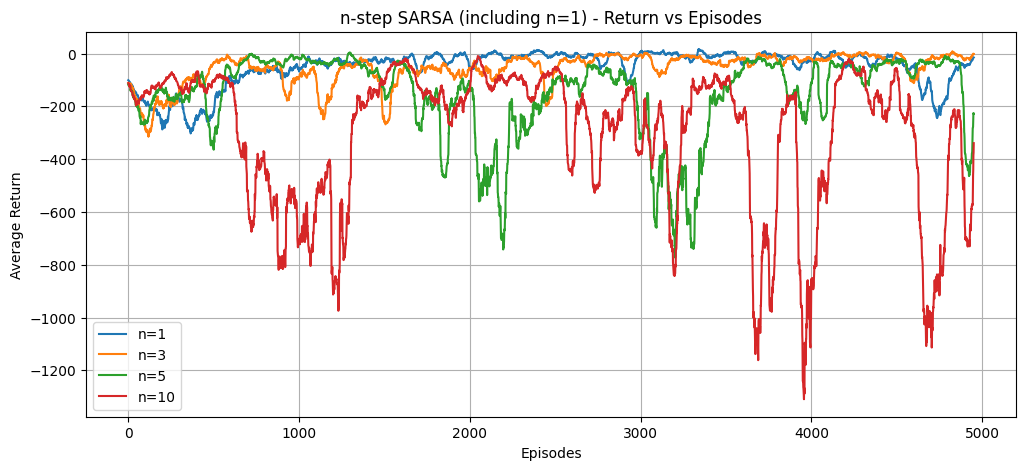

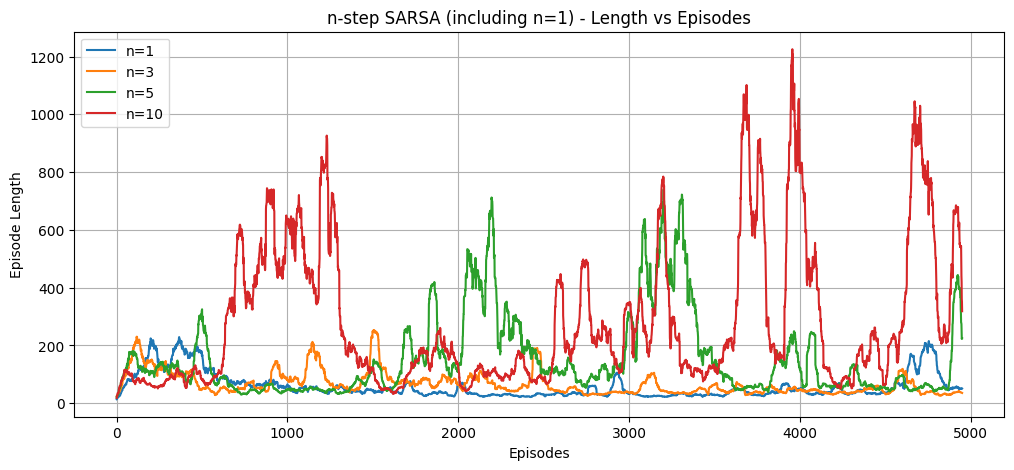

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def moving_avg(x, window=50):
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode='valid')

window = 50

# ---------- Returns ----------
plt.figure(figsize=(12,5))

for n in sorted(results.keys()):
    plt.plot(moving_avg(results[n]["returns"], window), label=f"n={n}")

plt.xlabel("Episodes")
plt.ylabel("Average Return")
plt.title("n-step SARSA (including n=1) - Return vs Episodes")
plt.legend()
plt.grid()


# ---------- Length ----------
plt.figure(figsize=(12,5))

for n in sorted(results.keys()):
    plt.plot(moving_avg(results[n]["lengths"], window), label=f"n={n}")

plt.xlabel("Episodes")
plt.ylabel("Episode Length")
plt.title("n-step SARSA (including n=1) - Length vs Episodes")
plt.legend()
plt.grid()

plt.show()

Q learning

In [30]:
def Q_to_V(Q, states, ACTIONS, terminal_states):
    """
    Converts Q(s,a) to V(s) = max_a Q(s,a)
    """
    V = {}
    for s in states:
        if s in terminal_states:
            V[s] = 0.0
        else:
            V[s] = max(Q[(s, a)] for a in ACTIONS)
    return V


def run_q_learning(states, terminal_states, ACTIONS, get_transitions,
                   V_optimal,
                   GAMMA=0.95,
                   alpha_start=0.1,
                   epsilon_start=0.1,
                   epsilon_min=0.01,
                   episodes=5000):

    import time
    import tracemalloc
    import random
    import numpy as np

    # Initialize Q(s,a)
    Q = {(s, a): 0.0 for s in states for a in ACTIONS if s not in terminal_states}

    returns = []
    lengths = []
    value_errors = []

    start_time = time.time()
    tracemalloc.start()

    non_terminal_states = [s for s in states if s not in terminal_states]

    alpha = alpha_start
    epsilon = epsilon_start

    for ep in range(episodes):

        state = random.choice(non_terminal_states)

        episode_return = 0
        episode_length = 0

        while state not in terminal_states:

            # ε-greedy policy
            if random.random() < epsilon:
                action = random.choice(ACTIONS)
            else:
                action = max(ACTIONS, key=lambda a: Q[(state, a)])

            transitions = get_transitions(state, action)
            probs = [t[0] for t in transitions]
            choice = np.random.choice(len(transitions), p=probs)
            _, next_state, reward = transitions[choice]

            episode_return += reward
            episode_length += 1

            # Q-learning update
            if next_state in terminal_states:
                target = reward
            else:
                best_next = max(Q[(next_state, a)] for a in ACTIONS)
                target = reward + GAMMA * best_next

            Q[(state, action)] += alpha * (target - Q[(state, action)])

            state = next_state

        returns.append(episode_return)
        lengths.append(episode_length)

        # ---- GLIE-style decay ----
        epsilon = max(epsilon_min, epsilon_start * (0.995 ** ep))
        alpha = alpha_start / (1 + 0.001 * ep)
        # --------------------------

        # Compute mean state value error (more stable than max error)
        V_current = Q_to_V(Q, states, ACTIONS, terminal_states)
        error = np.mean([abs(V_current[s] - V_optimal[s]) for s in V_optimal])
        value_errors.append(error)

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    # Extract greedy policy
    policy = {}
    for s in states:
        if s in terminal_states:
            continue
        policy[s] = max(ACTIONS, key=lambda a: Q[(s, a)])

    return Q, policy, runtime, peak, returns, lengths, value_errors


Q_q, policy_q, time_q, mem_q, returns_q, lengths_q, value_errors_q = run_q_learning(states, terminal_states, ACTIONS, get_transitions, V_vi)

In [31]:
def moving_avg(x, window=50):
    import numpy as np
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode='valid')

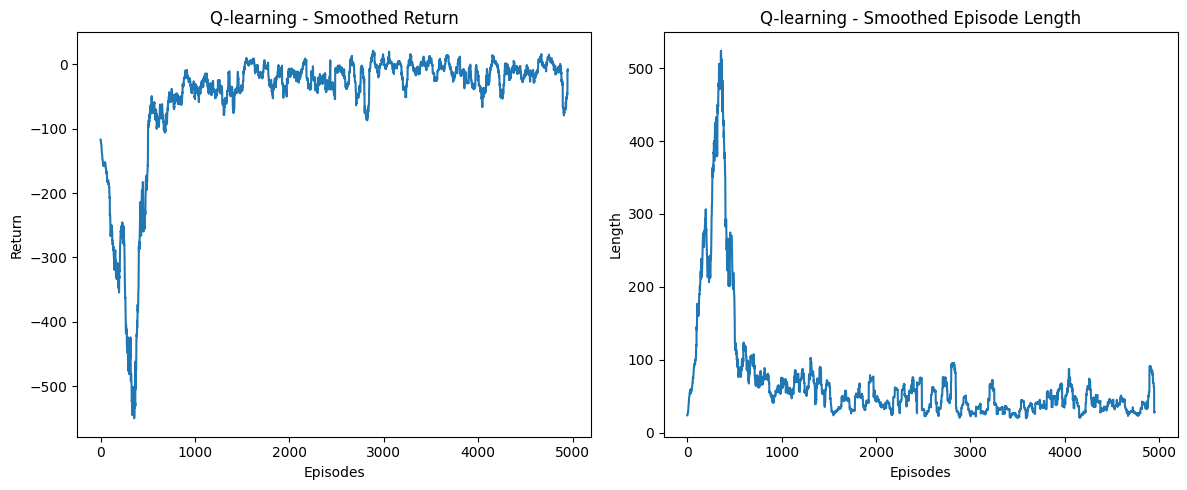

In [32]:
import matplotlib.pyplot as plt

window = 50

plt.figure(figsize=(12,5))

# Return
plt.subplot(1,2,1)
plt.plot(moving_avg(returns_q, window))
plt.title("Q-learning - Smoothed Return")
plt.xlabel("Episodes")
plt.ylabel("Return")

# Length
plt.subplot(1,2,2)
plt.plot(moving_avg(lengths_q, window))
plt.title("Q-learning - Smoothed Episode Length")
plt.xlabel("Episodes")
plt.ylabel("Length")

plt.tight_layout()
plt.show()

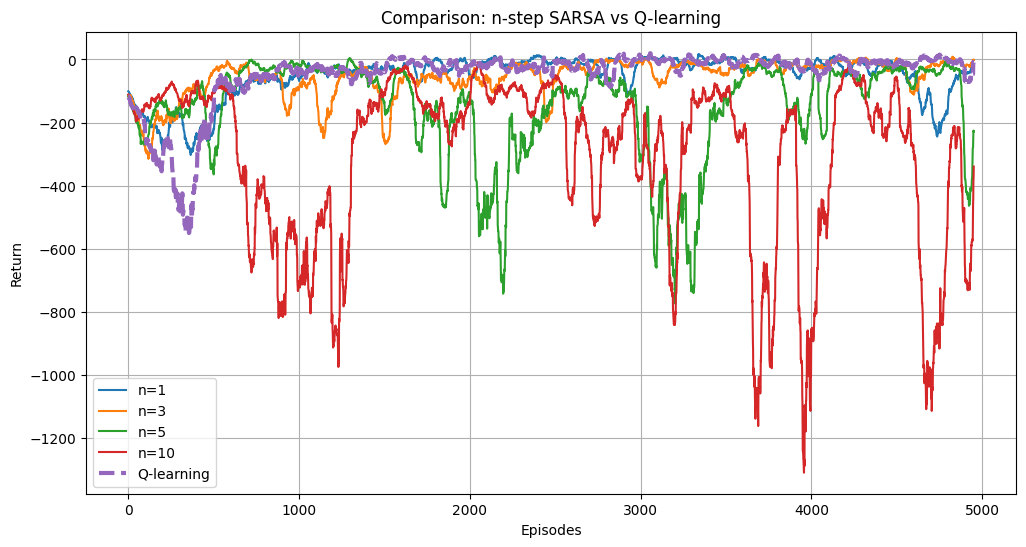

In [33]:
plt.figure(figsize=(12,6))

# n-step SARSA (including n=1)
for n in sorted(results.keys()):
    plt.plot(moving_avg(results[n]["returns"], window), label=f"n={n}")

# Q-learning
plt.plot(moving_avg(returns_q, window), label="Q-learning", linewidth=3, linestyle='--')

plt.xlabel("Episodes")
plt.ylabel("Return")
plt.title("Comparison: n-step SARSA vs Q-learning")
plt.legend()
plt.grid()
plt.show()

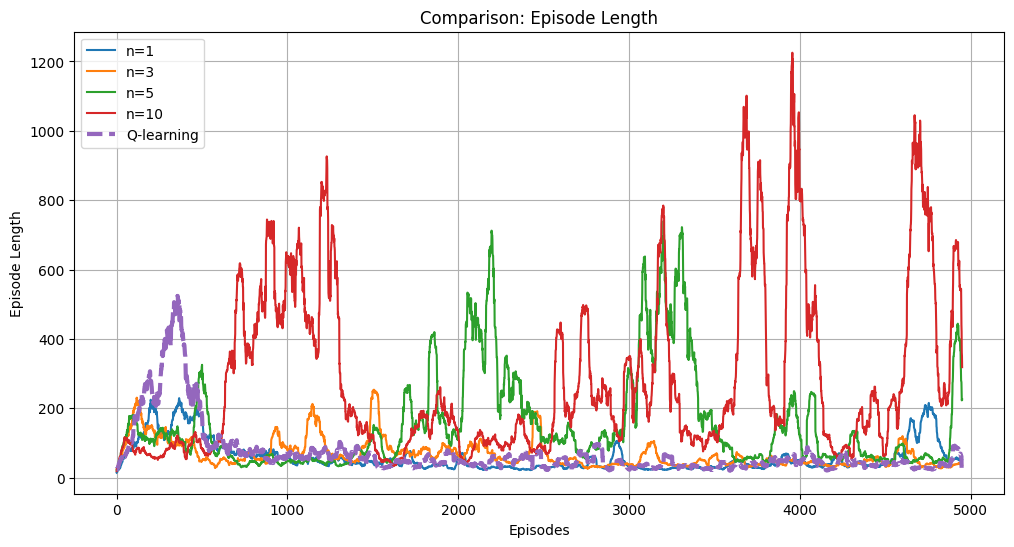

In [34]:
plt.figure(figsize=(12,6))

for n in sorted(results.keys()):
    plt.plot(moving_avg(results[n]["lengths"], window), label=f"n={n}")

plt.plot(moving_avg(lengths_q, window), label="Q-learning", linewidth=3, linestyle='--')

plt.xlabel("Episodes")
plt.ylabel("Episode Length")
plt.title("Comparison: Episode Length")
plt.legend()
plt.grid()
plt.show()

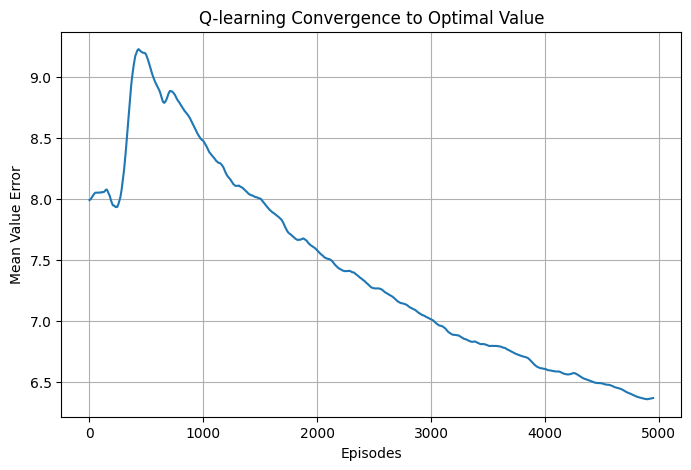

In [35]:
plt.figure(figsize=(8,5))

plt.plot(moving_avg(value_errors_q, window))
plt.xlabel("Episodes")
plt.ylabel("Mean Value Error")
plt.title("Q-learning Convergence to Optimal Value")
plt.grid()

plt.show()

In [36]:
print("\nFinal Performance Comparison\n")

print(f"{'Method':<20} {'Time (s)':<10} {'Memory (KB)':<12}")
print("-"*45)

print(f"{'Value Iteration':<20} {vi_time:<10.4f} {vi_mem/1024:<12.2f}")
print(f"{'Policy Iteration':<20} {pi_time:<10.4f} {pi_mem/1024:<12.2f}")

for n in sorted(results.keys()):
    print(f"{f'n-step SARSA (n={n})':<20} {results[n]['time']:<10.4f} {results[n]['mem']/1024:<12.2f}")

print(f"{'Q-learning':<20} {time_q:<10.4f} {mem_q/1024:<12.2f}")


Final Performance Comparison

Method               Time (s)   Memory (KB) 
---------------------------------------------
Value Iteration      0.3508     56.68       
Policy Iteration     1.2484     53.87       
n-step SARSA (n=1)   9.0024     200.71      
n-step SARSA (n=3)   14.4089    251.03      
n-step SARSA (n=5)   29.5984    832.87      
n-step SARSA (n=10)  55.5909    1045.01     
Q-learning           15.0842    373.05      
